In [ ]:
from __future__ import annotations

from pathlib import Path
from typing import Union
import math
import numpy as np
import polars as pl
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

from run_config import PATHS

VISUALIZATION_TIME_UNIT = "4h"  # local notebook selection

silver_census_tracts = PATHS.silver_census_tracts
silver_community_area = PATHS.silver_community_areas

SILVER_TAXI_PATH = PATHS.silver_taxi_community_areas_unfiltered
SILVER_WEATHER_PATH = PATHS.silver_weatherdata
SILVER_HEXAGON_PATH = PATHS.silver_hexagon

GOLD_TAXI_PATH = PATHS.gold_taxi_trips
GOLD_WEATHER_PATH = PATHS.gold_weatherdata
GOLD_DEMAND_PATHS = {
    "1h": (PATHS.gold_1h_demand_hexagon, PATHS.gold_1h_demand_census_tracts, PATHS.gold_1h_demand_community_areas),
    "2h": (PATHS.gold_2h_demand_hexagon, PATHS.gold_2h_demand_census_tracts, PATHS.gold_2h_demand_community_areas),
    "4h": (PATHS.gold_4h_demand_hexagon, PATHS.gold_4h_demand_census_tracts, PATHS.gold_4h_demand_community_areas),
}
(
    GOLD_HOURLY_DEMAND_HEXAGON,
    GOLD_HOURLY_DEMAND_CENSUS_TRACT,
    GOLD_HOURLY_DEMAND_COMMUNITY_AREA,
) = GOLD_DEMAND_PATHS[VISUALIZATION_TIME_UNIT]


def plot_chicago_demand_map(
    demand_data,
    geom_data,
    spatial_col: str,
    geom_key_col: str,
    demand_col: str = "trips_started",
    datetime_col: str = "datetime_hour",
    start_ts: str | None = None,
    end_ts: str | None = None,
    title: str | None = None,
    figsize: tuple[int, int] = (10, 10),
    agg: str = "sum",
    plot_boundary: bool = True,
    color_scale: str = "quantile",
    vmax_quantile: float = 0.98,
):

    # ----------------------------
    # 1. Demand dataset laden
    # ----------------------------
    if isinstance(demand_data, (str, Path)):
        demand_lf = pl.scan_parquet(str(demand_data))
    elif isinstance(demand_data, pl.DataFrame):
        demand_lf = demand_data.lazy()
    elif isinstance(demand_data, pl.LazyFrame):
        demand_lf = demand_data
    else:
        raise TypeError("demand_data must be a path, DataFrame, or LazyFrame")

    # Datetime auf konsistente Einheit bringen
    demand_lf = demand_lf.with_columns(
        pl.col(datetime_col).cast(pl.Datetime("us")).alias(datetime_col)
    )

    # Optionaler Zeitfilter
    if start_ts is not None:
        demand_lf = demand_lf.filter(
            pl.col(datetime_col) >= pl.lit(start_ts).str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
        )

    if end_ts is not None:
        demand_lf = demand_lf.filter(
            pl.col(datetime_col) <= pl.lit(end_ts).str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S")
        )

    # Aggregation je Raum
    if agg == "sum":
        demand_agg = (
            demand_lf
            .group_by(spatial_col)
            .agg(pl.col(demand_col).sum().alias(demand_col))
            .collect()
        )
    elif agg == "mean":
        demand_agg = (
            demand_lf
            .group_by(spatial_col)
            .agg(pl.col(demand_col).mean().alias(demand_col))
            .collect()
        )
    else:
        raise ValueError("agg must be one of: 'sum', 'mean'")

    # Schlüsselspalte robust auf String casten
    demand_agg = demand_agg.with_columns(
        pl.col(spatial_col).cast(pl.String)
    )

    # ----------------------------
    # 2. Geometrie laden
    # ----------------------------
    gdf_geom = gpd.read_parquet(geom_data)

    if "geometry" not in gdf_geom.columns:
        raise ValueError("Geometry dataset must contain a 'geometry' column")

    # CRS sicherstellen
    if gdf_geom.crs is None:
        gdf_geom = gdf_geom.set_crs("EPSG:4326")
    else:
        gdf_geom = gdf_geom.to_crs("EPSG:4326")

    # Join-Key als String
    gdf_geom[geom_key_col] = gdf_geom[geom_key_col].astype(str)

    # ----------------------------
    # 3. Demand an Geometrie joinen
    # ----------------------------
    demand_pd = demand_agg.to_pandas()

    gdf_plot = gdf_geom.merge(
        demand_pd,
        how="left",
        left_on=geom_key_col,
        right_on=spatial_col,
    )

    # Fehlende Räume = 0 Demand
    gdf_plot[demand_col] = gdf_plot[demand_col].fillna(0)

    # ----------------------------
    # 4. Boundary optional erzeugen
    # ----------------------------
    chicago_boundary = None
    if plot_boundary:
        chicago_boundary = gdf_plot.dissolve()

    # ----------------------------
    # 5. Color scaling
    # ----------------------------

    # 0 bleibt weiß, hohe Werte werden stärker eingefärbt
    cmap = LinearSegmentedColormap.from_list(
        "white_to_red",
        ["#ffffff", "#fee8c8", "#fdbb84", "#e34a33", "#b30000"],
    )

    values = gdf_plot[demand_col].fillna(0)

    plot_col = demand_col

    if color_scale == "linear":
        vmax = values.max()
        vmin = 0

    elif color_scale == "quantile":
        # Robust gegen wenige extreme Hotspots
        vmax = values.quantile(vmax_quantile)
        vmin = 0

        # Werte oberhalb des Quantils werden farblich gedeckelt
        plot_col = f"{demand_col}_clipped"
        gdf_plot[plot_col] = values.clip(lower=0, upper=vmax)

    elif color_scale == "log":
        # log1p funktioniert auch bei 0:
        # log1p(0) = 0
        plot_col = f"{demand_col}_log1p"
        gdf_plot[plot_col] = np.log1p(values)

        vmin = 0
        vmax = gdf_plot[plot_col].max()

    else:
        raise ValueError("color_scale must be one of: 'linear', 'quantile', 'log'")
    
    # ----------------------------
    # 6. Plot
    # ----------------------------
    fig, ax = plt.subplots(figsize=figsize)

    gdf_plot.plot(
        column=plot_col,
        ax=ax,
        cmap=cmap,
        linewidth=0.2,
        edgecolor="grey",
        legend=True,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={
            "color": "white",
            "label": "No data",
        },
    )

    if chicago_boundary is not None:
        chicago_boundary.boundary.plot(
            ax=ax,
            color="black",
            linewidth=1.0,
        )

    ax.set_title(title)
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

    return gdf_plot, ax

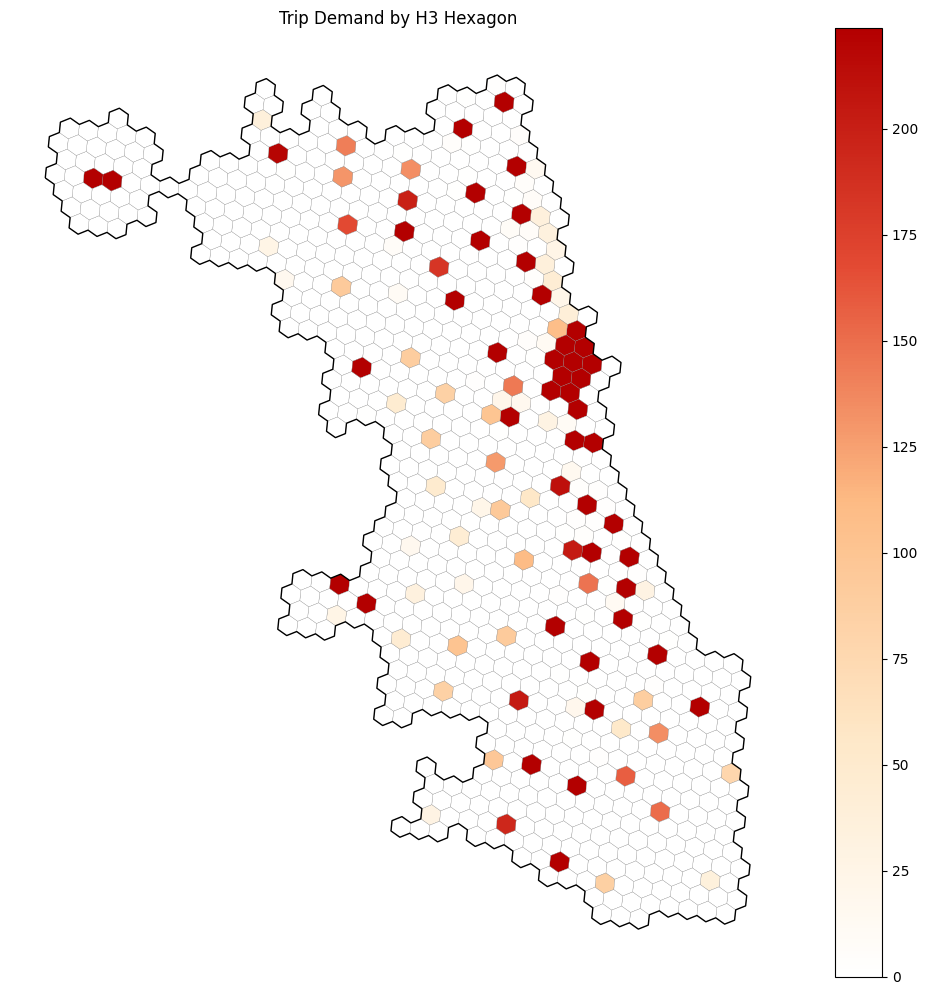

In [25]:
gdf_hex, ax = plot_chicago_demand_map(
    demand_data=GOLD_HOURLY_DEMAND_HEXAGON,
    geom_data=SILVER_HEXAGON_PATH,
    spatial_col="h3_cell",
    geom_key_col="h3_cell",
    demand_col="trip_start_timestamp",
    datetime_col="datetime_hour",
    start_ts="2024-02-01 00:00:00",
    end_ts="2024-02-07 23:00:00",
    agg="sum",
    title="Trip Demand by H3 Hexagon",
    color_scale="quantile",
    vmax_quantile=0.95,
)

This shows the problem with hexagons in regard to the given taxi data. As the location is always a centroid and often a centroid of the community area, the demand of a much larger area is pinpointed to one hexagon

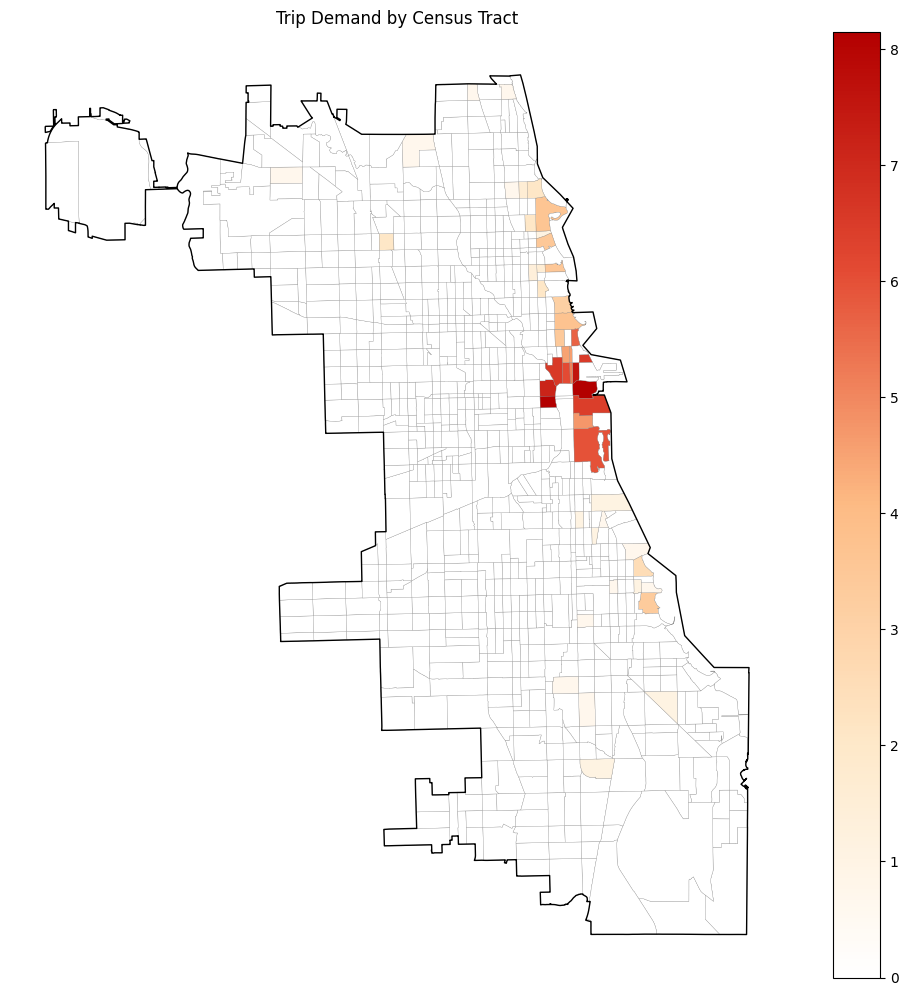

In [26]:
gdf_ct, ax = plot_chicago_demand_map(
    demand_data=GOLD_HOURLY_DEMAND_CENSUS_TRACT,
    geom_data=silver_census_tracts,
    spatial_col="census_tract",
    geom_key_col="CENSUS_T_1",
    demand_col="trip_start_timestamp",
    datetime_col="datetime_hour",
    start_ts="2024-02-01 00:00:00",
    end_ts="2024-02-07 23:00:00",
    agg="sum",
    title="Trip Demand by Census Tract",
    color_scale="log",
    vmax_quantile=0.95,
)

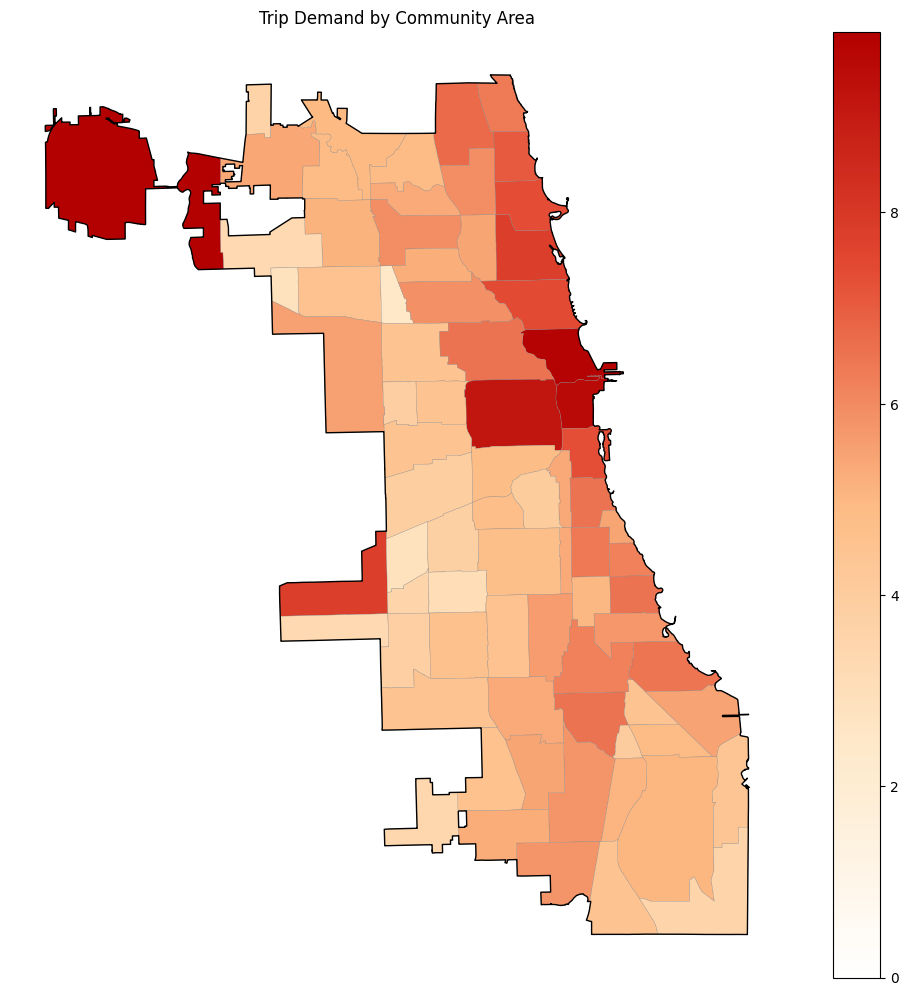

In [27]:
gdf_ca, ax = plot_chicago_demand_map(
    demand_data=GOLD_HOURLY_DEMAND_COMMUNITY_AREA,
    geom_data=silver_community_area,
    spatial_col="community_area",
    geom_key_col="AREA_NUM_1",  # ggf. an deinen echten Spaltennamen anpassen
    demand_col="trip_start_timestamp",
    datetime_col="datetime_hour",
    start_ts="2024-02-01 00:00:00",
    end_ts="2024-02-07 23:00:00",
    agg="sum",
    title="Trip Demand by Community Area",
    color_scale="log",
    vmax_quantile=0.95,
)